In [19]:
import matplotlib.pyplot as plt, pandas as pd, numpy as np, seaborn as sns, warnings as warn, matplotlib.pyplot as pl
%matplotlib inline
warn.filterwarnings('ignore')
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix

In [27]:
x = np.linspace(-5, 5, 100)
y = np.sqrt(100 - x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [21]:
x

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [22]:
y

array([ 8.66025404,  8.71779204,  8.77378994,  8.82827705,  8.88128118,
        8.93282873,  8.98294476,  9.03165312,  9.07897646,  9.12493632,
        9.16955321,  9.21284664,  9.25483518,  9.29553652,  9.3349675 ,
        9.37314414,  9.41008171,  9.44579475,  9.4802971 ,  9.51360192,
        9.54572176,  9.57666854,  9.60645359,  9.63508769,  9.66258107,
        9.68894344,  9.714184  ,  9.73831149,  9.76133416,  9.7832598 ,
        9.80409577,  9.82384901,  9.84252604,  9.86013297,  9.87667553,
        9.89215905,  9.90658851,  9.91996849,  9.93230325,  9.94359667,
        9.9538523 ,  9.96307334,  9.97126266,  9.9784228 ,  9.98455598,
        9.98966408,  9.99374868,  9.99681104,  9.99885209,  9.99987246,
        9.99987246,  9.99885209,  9.99681104,  9.99374868,  9.98966408,
        9.98455598,  9.9784228 ,  9.97126266,  9.96307334,  9.9538523 ,
        9.94359667,  9.93230325,  9.91996849,  9.90658851,  9.89215905,
        9.87667553,  9.86013297,  9.84252604,  9.82384901,  9.80

In [28]:
x1 = np.linspace(-5, 5, 100)
y1 = np.sqrt(100 - x**2)
y1 = np.hstack([y,-y])
x1 = np.hstack([x,-x])

<Axes: >

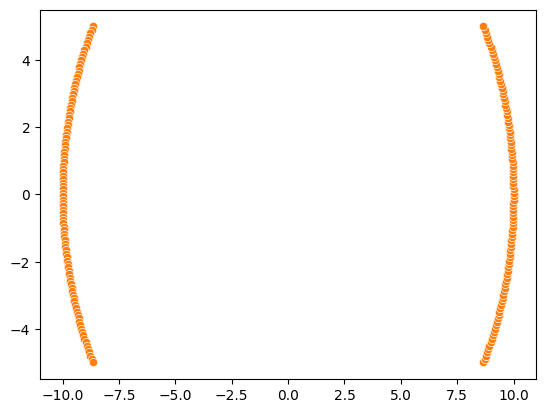

In [29]:
sns.scatterplot(x = y , y = x)
sns.scatterplot(x = y1, y = x1)

In [33]:
df1 = pd.DataFrame(np.vstack([y, x]).T, columns = ['X1', 'X2'])
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns = ['X1', 'X2'])
df1['Y'] = 0
df2['Y'] = 1
df = pd.concat([df1, df2], axis = 0, ignore_index = True)

In [34]:
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [35]:
df['X1_squared'] = df['X1']**2
df['X2_squared'] = df['X2']**2
df['X1*X2'] = df['X1']*df['X2']

In [36]:
X = df[['X1_squared', 'X2_squared', 'X1*X2']]
y = df['Y']
X_train , X_test , y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [41]:
svc = SVC(kernel = 'linear')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


In [42]:
svc = SVC(kernel = 'poly')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


In [43]:
svc = SVC(kernel = 'rbf')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


In [44]:
svc = SVC(kernel = 'sigmoid')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


## SVM Kernel Practical Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [ ]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

In [ ]:

plt.scatter(y,x)
plt.scatter(y1,x1)

In [ ]:
import pandas as pd
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], axis = 0, ignore_index= True)
df.head(5)

In [ ]:
df.tail()

## Polynomial Kernel
![image.png](attachment:f72cba6f-7dc4-4e85-8e9f-14b91eccd919.png)

## Based on the formula find the componenets for the Polynomial kernel

In [ ]:
df['X1_Square']=df['X1']**2
df['X2_Square']=df['X2']**2
df['X1*X2']=df['X1']*df['X2']
df.head()

In [ ]:
### Independent and Dependent features
X = df[['X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = 0)

In [ ]:
X_train.head()

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
!pip install plotly

In [ ]:
df.head()

In [ ]:
import plotly.express as px
import plotly.express as px
fig = px.scatter_3d(df, x='X1_Square', y='X2_Square', z='X1*X2',
              color='Y')
fig.show()
plt.show()


In [37]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


In [39]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


In [40]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.6
[[ 0 60]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.60      1.00      0.75        90

    accuracy                           0.60       150
   macro avg       0.30      0.50      0.38       150
weighted avg       0.36      0.60      0.45       150

0.6
1.0


## Radial Basis Function Kernel
![image.png](attachment:2350c8c5-a535-4822-9953-16e0df479498.png)

In [ ]:
df.head()

In [ ]:
## Indpeendent Features
X=df.iloc[:,0:2]
y=df.Y

In [ ]:
X.head()

In [ ]:
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = 0)

In [ ]:
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

In [ ]:
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

## Sigmoid Kernel
![image.png](attachment:126a0dc3-e516-49d3-a34d-f342e6491ee3.png)

In [ ]:
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)